# Centriole labels colocalisation analysis.

## Dataset: 4-6 hpf Cetn2:GFP & CS

This script will focus on the positional analysis of the centriole markers Centrin2:GFP and CenSpark. The goal is to determine wherether Centrin2 and CenSpark label the centriole correct position or not. If both label are visible at the same location, then we can hypothesis that a centriole has been localized. 

In [3]:
import os
import time
import tifffile
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from itertools import product
from tqdm import tqdm
from pathlib import Path
from stardist.models import StarDist3D
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.filters import threshold_otsu
from itertools import product
from scipy.spatial import distance_matrix
from scipy.optimize import linear_sum_assignment

import sys
sys.path.append(r"K:\users\voland\Code\Zfish_Centrioles_Tracking_Pipeline")
from segmentation.centriole import stardist_segmentation

%matplotlib inline

## Data

In [14]:
IMG_PATH = r"K:\users\voland\images\cova_data\ZF_colocalisation\4-6hpf_CetnGFP_CS\original\20260115CFHa_CetnGFP_CS_TL_4-6hpf_e4_t1-7.tif"
FRAMES = 7

In [ ]:
start_time = time.time()
vol = tifffile.memmap(IMG_PATH)
print(f"Openning the image took {(time.time() - start_time):.2f} seconds")

Openning the image took 0.65 seconds


## Image analysis

Before going to deep in the semgentation pipeline, we need to analyse our image and better understand it.
Let's first start with some general analysis.

In [37]:
print(f"Image shape: {vol.shape} \n")

CT_intensities = vol[:,:,0].flatten()
CS_intensities = vol[:,:,1].flatten()

print("Cetn2:GFP intensity metrics:")
print(f"Min value: {CT_intensities.min()}")
print(f"Max value: {CT_intensities.max()}")
print(f"Mean value: {CT_intensities.mean():.1f}")
print(f"Median value: {np.median(CT_intensities):.1f} \n")

print("CenSpark intensity metrics:")
print(f"Min value: {CS_intensities.min()}")
print(f"Max value: {CS_intensities.max()}")
print(f"Mean value: {CS_intensities.mean():.1f}")
print(f"Median value: {np.median(CS_intensities):.1f}")

Image shape: (7, 80, 3, 1024, 1024) 

Cetn2:GFP intensity metrics:
Min value: 0
Max value: 255
Mean value: 1.4
Median value: 0.0 

CenSpark intensity metrics:
Min value: 0
Max value: 255
Mean value: 2.3
Median value: 0.0


The shape of the dataset corresponds to (T,Z,C,Y,X). 
With the following channel configuration: 
- C0: Cetn2:GFP [green]
- C1: CenSpark [magenta]
- C2: Normal

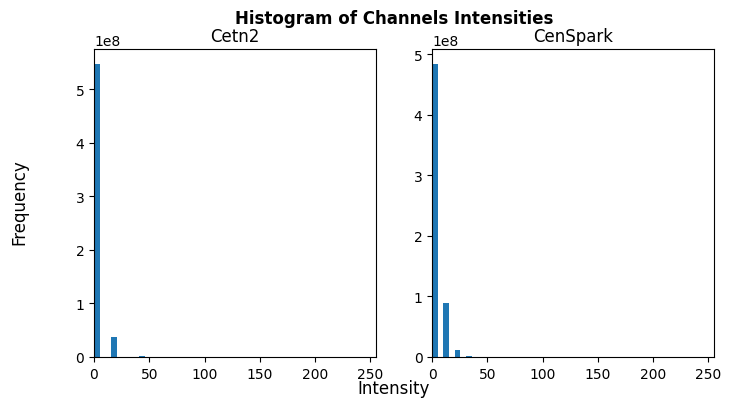

In [56]:
fig, axes = plt.subplots(1,2, figsize = (8,4))
axes[0].hist(CT_intensities, bins = 50)
axes[0].set_title('Cetn2')
axes[0].set_xlim(0, CT_intensities.max())
axes[1].hist(CS_intensities, bins = 50)
axes[1].set_title('CenSpark')
axes[1].set_xlim(0, CS_intensities.max())
fig.suptitle("Histogram of Channels Intensities", fontweight='bold')
fig.supxlabel('Intensity')
fig.supylabel('Frequency')
plt.show()

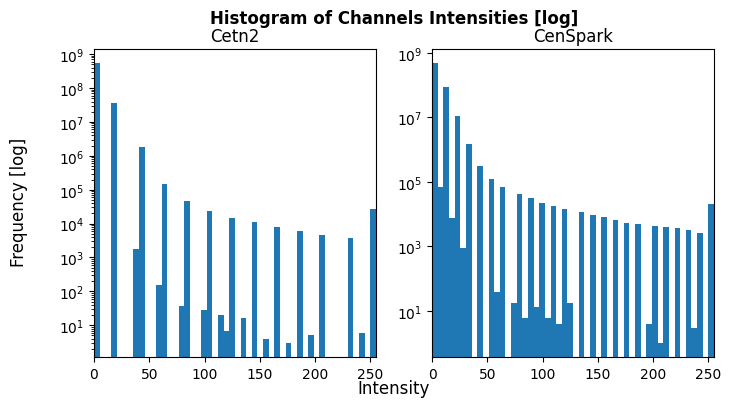

In [55]:
fig, axes = plt.subplots(1,2, figsize = (8,4))
axes[0].hist(CT_intensities, bins=50, log=True)
axes[0].set_title('Cetn2')
axes[0].set_xlim(0, CT_intensities.max())
axes[1].hist(CS_intensities, bins=50, log=True)
axes[1].set_title('CenSpark')
axes[1].set_xlim(0, CS_intensities.max())
fig.suptitle("Histogram of Channels Intensities [log]", fontweight='bold')
fig.supxlabel('Intensity')
fig.supylabel('Frequency [log]')
plt.show()

These histograms reveals that the images is highly saturated, where the centrioles bright spots have very high values compared to the rest.

Let's focus on the bright spots, by filtering all values below 

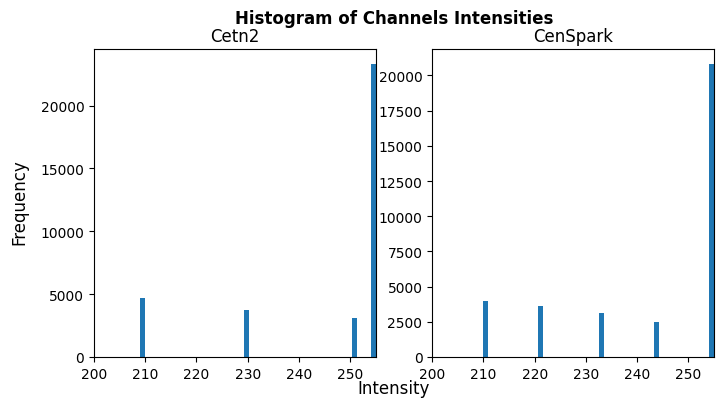

In [65]:
fig, axes = plt.subplots(1,2, figsize = (8,4))
axes[0].hist(CT_intensities[CT_intensities > 200], bins = 50)
axes[0].set_title('Cetn2')
axes[0].set_xlim(200, CT_intensities.max())
axes[1].hist(CS_intensities[CS_intensities > 200], bins = 50)
axes[1].set_title('CenSpark')
axes[1].set_xlim(200, CS_intensities.max())
fig.suptitle("Histogram of Channels Intensities", fontweight='bold')
fig.supxlabel('Intensity')
fig.supylabel('Frequency')
plt.show()

## 3D spots detection

To perform a colocalisation analysis of our marker, we need to determine the center of the labeled centrioles for each marker and then corrolate their location. To do so, we need to detect the 3D position of the center of the labeled centrioles.


### Methods 
For 3D segmentation, we could either use Deep Learning methods, such as StarDist or Cellpose, or more traditional technic, such as Log or Dog filter.
From our previous analysis, we noticed that the images are highly saturated and constrated making normalisation almost impossible. As Deep Learning method need normalized images, we decided to opt for more traditional method which aren't impacted much by this.

#### Deep learning methods 

##### Stardist

I still would like to try Startdist on my non-normalised image and see how it behaves.
Let's first take a 3D images at a specific frame.

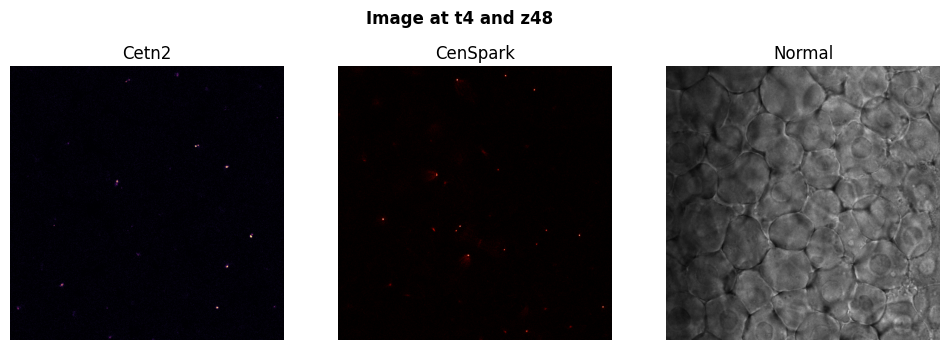

In [70]:
t = 3
z = 47
img = vol[t, z] #In Fiji this corresponds to the image at t6 and z15
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img[0], cmap="inferno")
axes[0].set_title("Cetn2")
axes[0].axis('off')
axes[1].imshow(img[1], cmap="gist_heat")
axes[1].set_title("CenSpark")
axes[1].axis("off")
axes[2].imshow(img[2], cmap="gray")
axes[2].set_title("Normal")
axes[2].axis("off")
fig.suptitle(f"Image at t{t+1} and z{z+1}", fontweight='bold')

plt.show()

Let's take the slices around this specific image to test our Deep learning model.

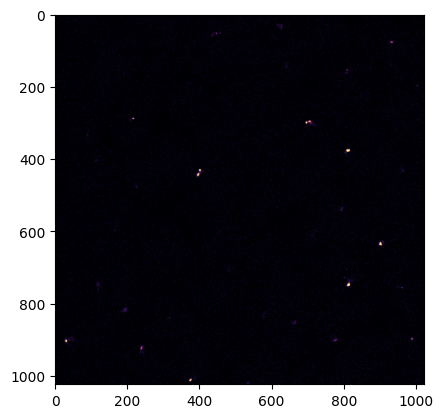

In [71]:
ex_frame = vol[t,45:49,0]
plt.imshow(ex_frame[0], cmap="inferno")

In [ ]:
print(f"Image shape: {ex_frame.shape}")
print(f"Min value: {ex_frame.min()}")
print(f"Max value: {ex_frame.max()}")
print(f"Mean value: {ex_frame.mean():.1f}")

Image shape: (4, 1024, 1024)
Min value: 0
Max value: 255
Mean value: 2.1
Unique values: [  0  19  20  38  41  58  62  83 104 125 146 167 188 209 230 251 255]


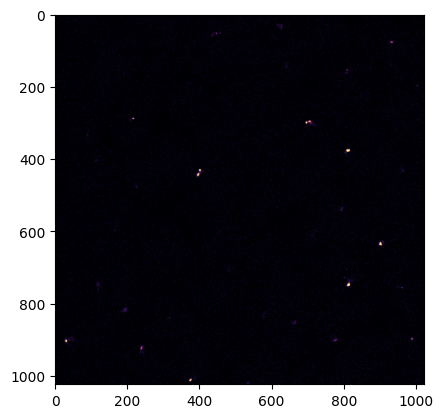

In [ ]:
vol_axis = ex_frame.shape[0]
ex_norm_frame = np.empty(ex_frame.shape)
for idx in range(ex_frame.shape[0]):
    slice = ex_frame[idx]
    ex_norm_frame[idx] = (slice - slice.min()) / (slice.max() - slice.min())

plt.imshow(ex_norm_frame[0], cmap="inferno")

In [ ]:
ex_norm_frame = stardist_segmentation.normalizesFrame(ex_frame)

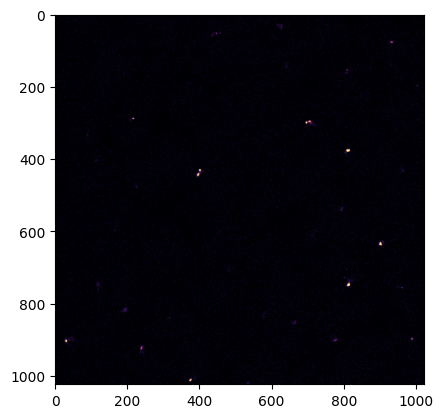

In [98]:
from csbdeep.utils import Path, normalize

Z= ex_frame.shape[0]
ex_norm_frame = np.empty(ex_frame.shape)
for z in range(Z):
        img = ex_frame[z]
        ex_norm_frame[z] = normalize(img, 1,99.8)
plt.imshow(ex_norm_frame[0], cmap="inferno")

In [99]:
print(f"Image shape: {ex_norm_frame.shape}")
print(f"Min value: {ex_norm_frame.min()}")
print(f"Max value: {ex_norm_frame.max()}")
print(f"Mean value: {ex_norm_frame.mean():.1f}")
print(f"Unique values: {np.unique(ex_norm_frame)}")

Image shape: (4, 1024, 1024)
Min value: 0.0
Max value: 6.219511985778809
Mean value: 0.1
Unique values: [0.         0.46341464 0.48780489 0.92682928 1.         1.41463411
 1.51219511 2.02439022 2.53658533 3.04878044 3.56097555 4.07317066
 4.58536577 5.09756088 5.60975599 6.1219511  6.21951199]


Unifortunately with these normalisation, the image is binarised, aka already segmented, which doesn't really work with what we attempt to do. 

In [82]:
model = StarDist3D.from_pretrained('3D_demo')

Found model '3D_demo' for 'StarDist3D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.707933, nms_thresh=0.3.


As the process is quite long, I set up here a toggable variable to control

In [ ]:
run_stardist = True
if run_stardist:
    start_time = time.time()
    labels, polys = model.predict_instances(
        ex_norm_frame,  # The image must be normalized
        axes="ZYX",
        prob_thresh=0.5,  # Detection probability threshold
        nms_thresh=0.1,  # Remove detections overlapping by more than this threshold
        scale=2,  # Higher valuecd s are suitable for lower resolution data
        return_labels=True,
    )
    print(f"Detecting the images took {(time.time() - start_time):.2f} seconds")

In [ ]:
polys["points"].shape

(271, 3)

This really didn't work. We couldn't find anything. <br>
Let's just put placeholder in them to see how it could look like 

In [ ]:
placeholer = np.array([1,2,3])
polys["dist"] = placeholer
polys["points"] = placeholer
polys["prob"] = placeholer
pd.DataFrame({"dist": polys["dist"], "points": polys["points"], "prob": polys["prob"]})

,dist,points,prob
0,1,1,1
1,2,2,2
2,3,3,3


#### Blob Detection using Log, Dog and DoH

To detect "blobs", bright spots on dark background, [scikit-image](https://scikit-image.org/docs/0.23.x/auto_examples/features_detection/plot_blob.html#sphx-glr-auto-examples-features-detection-plot-blob-py) suggest the three following algorithms: 
- Laplacian of Gaussian (LoG)
- Difference of Gaussian (DoG)
- Determinant of Hessian (DoH)

Each method has its own advantages and disadvantages which can be found on their website. 
Let's select an image at a specific slice and frame to study these methods. 

TypeError: Invalid shape (1024,) for image data

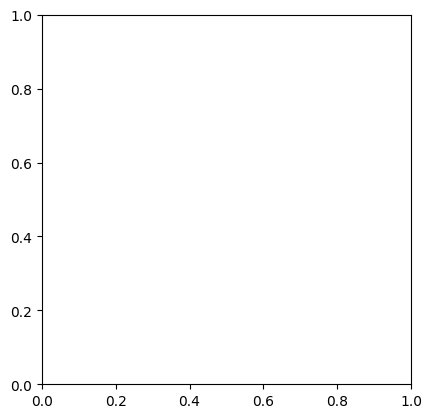

In [85]:
c = 1
img_C1 = img[c]
plt.imshow(img_C1)

In [ ]:
blobs_log = blob_log(img_C1, max_sigma=4, threshold=0.16)

# Compute radii in the 3rd column.
blobs_log[:, 2] = blobs_log[:, 2] * math.sqrt(2)

blobs_dog = blob_dog(img_C1, max_sigma=4, threshold=0.10)
blobs_dog[:, 2] = blobs_dog[:, 2] * math.sqrt(2)

blobs_doh = blob_doh(img_C1, max_sigma=20, threshold=0.01)

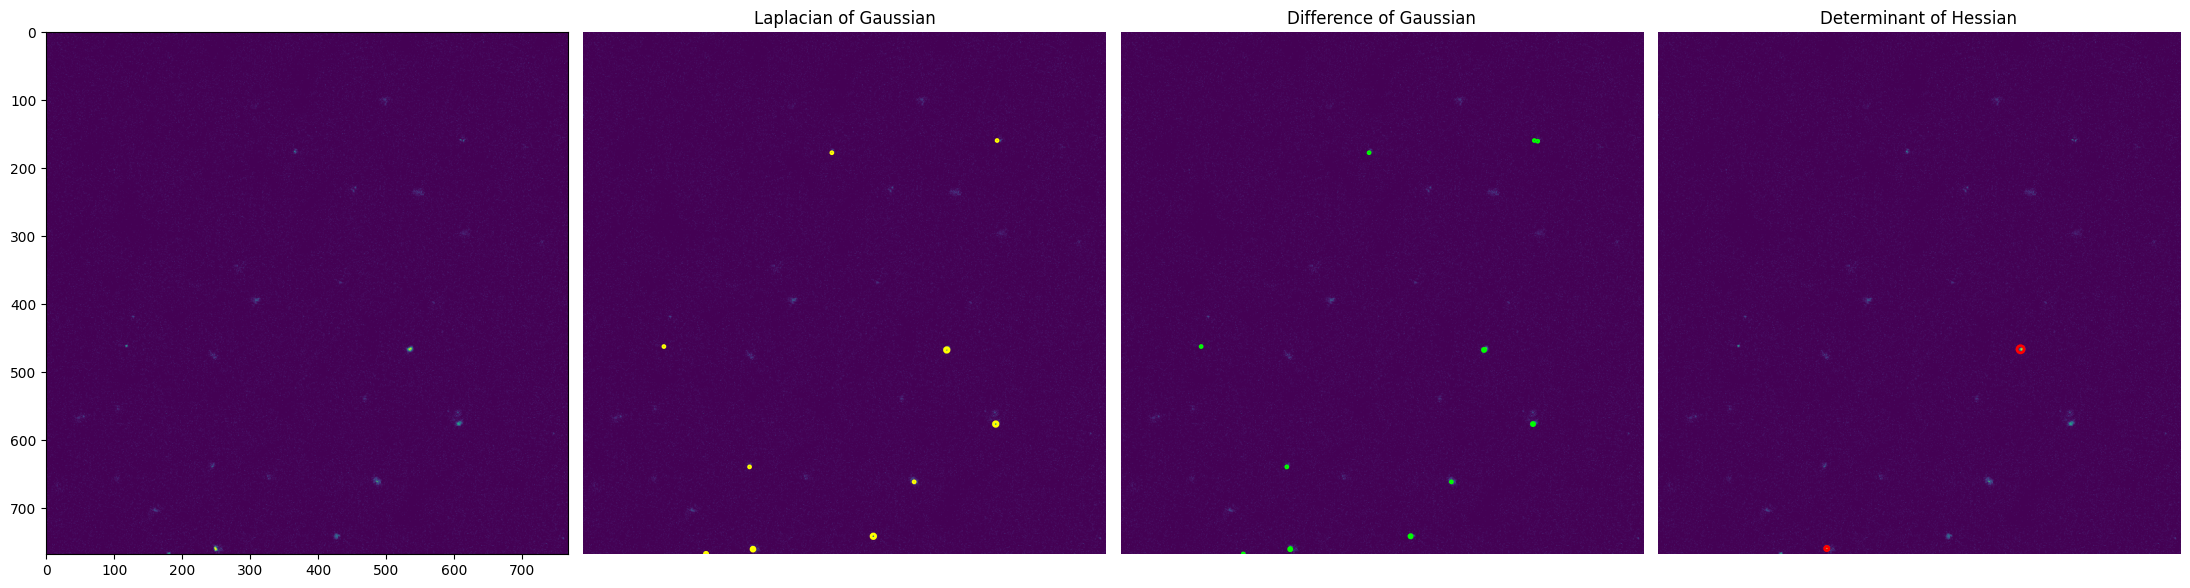

In [ ]:
blobs_list = [blobs_log, blobs_dog, blobs_doh]
colors = ['yellow', 'lime', 'red']
titles = ['Laplacian of Gaussian', 'Difference of Gaussian', 'Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)

fig, axes = plt.subplots(1, 4, figsize=(22, 8), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(img_C1)

for idx, (blobs, color, title) in enumerate(sequence):
    ax[idx + 1].set_title(title)
    ax[idx + 1].imshow(img_C1)
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
        ax[idx +1].add_patch(c)
    ax[idx+1].set_axis_off()

plt.tight_layout()
plt.show()

We can see that LoG and DoG filter have can output very similar results if fine tune correctly. 

In [ ]:
print(f"Number of blobs detected: {len(blobs_dog)}")
blobs_dog

Number of blobs detected: 11


array([[760.        , 249.        ,   2.2627417 ],
       [467.        , 534.        ,   2.2627417 ],
       [462.        , 118.        ,   1.41421356],
       [767.        , 180.        ,   1.41421356],
       [576.        , 606.        ,   2.2627417 ],
       [661.        , 486.        ,   1.41421356],
       [177.        , 365.        ,   1.41421356],
       [159.        , 608.        ,   1.41421356],
       [741.        , 426.        ,   2.2627417 ],
       [639.        , 244.        ,   1.41421356],
       [160.        , 613.        ,   1.41421356]])

These function returns the x and y coordinates of the center of the detected blobs. 
Let's also note that these functions can be used for 3D images. This is particularly as our dataset set is in 3D. 

### Results 

#### Blob Detection using DoG filter

By running `blob_detection()` method from the `blob_detection.py` script, we were able to obtain a labeled images and the coordinate of the blob center.

In [ ]:
C0_BLOB_CENTER_IMG_PATH = r"K:\users\voland\images\cova_data\ZF_colocalisation\4-6hpf_CetnGFP_CS\results\blob_detection\C0_results\C0_detected_img.tif"
C1_BLOB_CENTER_IMG_PATH = r"K:\users\voland\images\cova_data\ZF_colocalisation\4-6hpf_CetnGFP_CS\results\blob_detection\C1_results\C1_detected_img.tif"

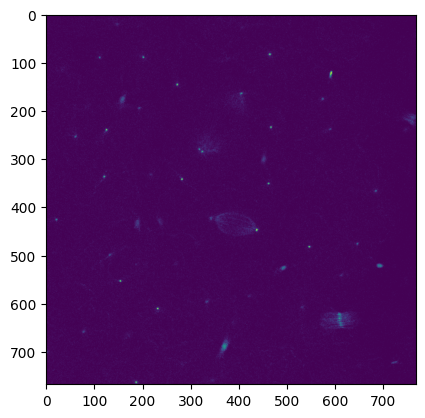

In [ ]:
CT_res_vol = tifffile.imread(C0_BLOB_CENTER_IMG_PATH)
CS_res_vol = tifffile.imread(C1_BLOB_CENTER_IMG_PATH)

res_img = CS_res_vol[t,z,0]
plt.imshow(res_img)

Text(0.5, 0.98, 'Blob detection on image at t5 and z14 for CenSparl')

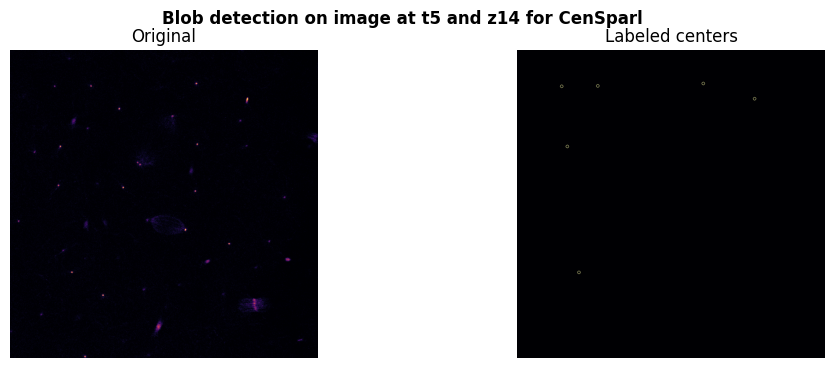

In [ ]:
res_img = CS_res_vol[t, z] #In Fiji this corresponds to the image ate t4 and z20
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].imshow(res_img[0], cmap="inferno")
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(res_img[1], cmap="inferno")
axes[1].set_title("Labeled centers")
axes[1].axis("off")
fig.suptitle(f"Blob detection on image at t{t} and z{z} for CenSparl", fontweight='bold')

Analysing these labeled images at a specific slice isn't really usefull. For a more detailed analysis please check my documents on the Drive.

## Colocalisation
In this next step we are going to associate CenSpark labeled centrioles with Cetn2 labled centrioles.

In [ ]:
C0_BLOB_CENTER_PATH = r"K:\users\voland\images\cova_data\ZF_colocalisation\4-6hpf_CetnGFP_CS\results\blob_detection\C0_results\C0_center_coord.csv"
C1_BLOB_CENTER_PATH = r"K:\users\voland\images\cova_data\ZF_colocalisation\4-6hpf_CetnGFP_CS\results\blob_detection\C1_results\C1_center_coord.csv"

In [ ]:
CT_center_df = pd.read_csv(C0_BLOB_CENTER_PATH)
CT_center_df

,index,T,Z,Y,X,R
0,0,0.0,20.0,485.0,531.0,1.6
1,1,0.0,48.0,562.0,590.0,1.6
2,2,0.0,48.0,343.0,266.0,1.6
3,3,0.0,44.0,275.0,620.0,1.6
4,4,0.0,32.0,619.0,546.0,1.6
...,...,...,...,...,...,...
1557,1557,6.0,16.0,545.0,609.0,1.0
1558,1558,6.0,73.0,303.0,117.0,1.0
1559,1559,6.0,79.0,581.0,441.0,1.0
1560,1560,6.0,55.0,196.0,502.0,1.0


In [ ]:
CS_center_df = pd.read_csv(C1_BLOB_CENTER_PATH)
CS_center_df

,index,T,Z,Y,X,R
0,0,0.0,15.0,490.0,269.0,1.0
1,1,0.0,71.0,342.0,299.0,1.6
2,2,0.0,32.0,88.0,738.0,1.0
3,3,0.0,17.0,660.0,445.0,1.6
4,4,0.0,27.0,428.0,621.0,1.0
...,...,...,...,...,...,...
1512,1512,6.0,10.0,179.0,95.0,1.0
1513,1513,6.0,71.0,132.0,695.0,1.0
1514,1514,6.0,76.0,609.0,69.0,1.0
1515,1515,6.0,41.0,274.0,758.0,1.0


We can first notice that there are more spots detected from the channel 0 (CenSpark) than the channel 1 (Cetn2) but that globally we have a very similar number of spots detected which is reasurring.

We aren't really interested by the distances between all the labeled centriole. We are rather interest by their nearest neighbours, their minial distance. Indeed we want to match CenSpark with Cetn2 labeled centrioles. Thus for each point we must determine its closest neighbours, if any close enough.

### Assignment problem solving 
Finding the most optimal pairs is an assignment problem and multiple already implemented exist to solve it. 
We decided to use [scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html) `linear_sum_assigment` function.

Let's also recall that we should get the distance matrix and the optimal pairs for each frame of our dataset.

In [ ]:
results = []

for frame in range(FRAMES):
    # We should work frame by frame as colocalisation only makes sense for the same temporality
    CT_center_df_t = CT_center_df[CT_center_df["T"] == frame]
    CS_center_df_t = CS_center_df[CS_center_df["T"] == frame]

    CT_pos = CT_center_df_t[["X", "Y", "Z"]].values
    CS_pos = CS_center_df_t[["X", "Y", "Z"]].values

    dist_matrix = distance_matrix(CS_pos,CT_pos)

    opti_row, opti_col = linear_sum_assignment(dist_matrix)

    results.append(pd.DataFrame({
        "CT_idx": CT_center_df_t.index[opti_col],
        "CS_idx": CS_center_df_t.index[opti_row],
        "dist": dist_matrix[opti_row, opti_col],
        "T" : frame
    }))

pair_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()


In [ ]:
pair_df

,CT_idx,CS_idx,dist,T
0,205,0,2.449490,0
1,157,1,36.578682,0
2,195,2,1.414214,0
3,4,3,110.031814,0
4,128,4,1.000000,0
...,...,...,...,...
1402,1550,1509,41.545156,6
1403,1452,1510,34.423829,6
1404,1519,1513,2.828427,6
1405,1487,1515,6.324555,6


In [ ]:
pair_dist = pair_df["dist"]
print("Nearest neighbour  between CenSark and Cetn2")
print(f"Number of CenSpark labeled spots: {len(pair_dist)}")
print(f"Min distance: {pair_dist.min():.2f}")
print(f"Max distance: {pair_dist.max():.2f}")
print(f"Mean distance: {pair_dist.mean():.2f}")
print(f"Median distance: {np.median(pair_dist)}")

Nearest neighbour  between CenSark and Cetn2
Number of CenSpark labeled spots: 1407
Min distance: 0.00
Max distance: 250.53
Mean distance: 26.86
Median distance: 7.483314773547883


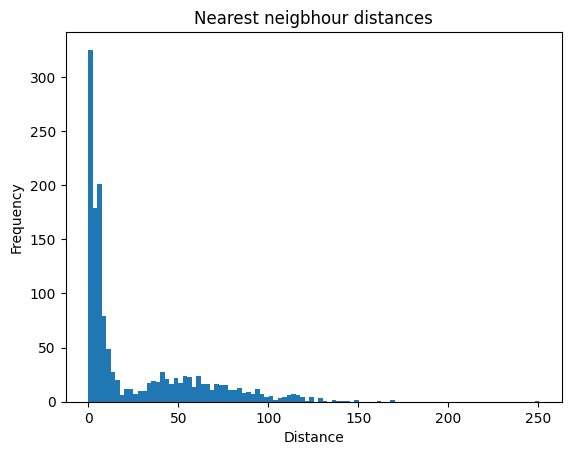

In [ ]:
plt.hist(pair_dist, bins=100)
plt.title("Nearest neigbhour distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.show()

We estimate that most centriole detected by CenSpark have a very close nearest neighbour that correspond to the Cetn2 label. Any largest distance most likely mean that the centriole is labeled correclty by only one marker. 
Let's zoom at the small distance in the graph to determine this distance.

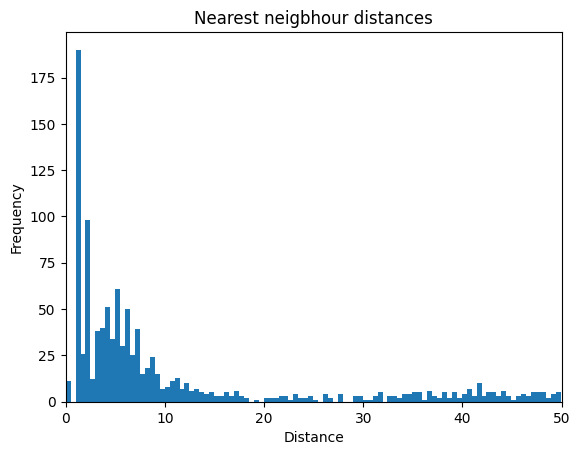

In [ ]:
zoomed_pair_dist = pair_dist[pair_dist < 50]
plt.hist(zoomed_pair_dist, bins=100)
plt.title("Nearest neigbhour distances")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.xlim(0,50)
plt.show()

It seems that the majority of the closest nearest neighbour are located at a distance of approximately 1.5.
We must determine the threshold which indicates the maximal distances between 2 labels before they mostly aren't related. Pair below this threshold are assumed to label the same centriole.
Let's first try with the value 13. We can now reuse our vector of nearest neibours and only keep the ones that are below this threshold. Spots removed from the vector are considered as spots without corresponding spot in the other channel.

In [ ]:
threshold = 20

In [ ]:
label_pair_df = pair_df[pair_df["dist"] <= threshold]

With such threshold, let's estimate what percentage of the centriole are paired. 

In [ ]:
proportion_pair = len(label_pair_df['dist']) / len(pair_df['dist']) * 100
print(f"Percentage of paired label: {proportion_pair}")

Percentage of paired label: 62.97085998578535


We can reuse the image with marker center labeled and add a number on top of the paired centers.

In [ ]:
CS_res_vol.shape

(7, 80, 2, 768, 768)

In [ ]:
def annotate_pairing_mask(text, idx, center_df, mask, radius = 4, font = cv2.FONT_HERSHEY_COMPLEX_SMALL):
    (x, y, z) = center_df[["X","Y","Z"]].loc[idx].values

    y_max, x_max = mask.shape[-2:]
    x_offset = 2
    y_offset = 5
    xy_offset = (int(np.clip(x + x_offset,0, x_max)), int(np.clip(y - y_offset, 0, y_max)))

    cv2.putText(img = mask[int(z)],text= text,org= xy_offset,fontFace= font,fontScale= 0.4,color = (255),thickness= 1,lineType= cv2.LINE_AA)

In [ ]:
[T, Z, C, X, Y] = vol.shape
mask_vol = np.empty((T,Z,4,Y,X),dtype=np.uint8)
for frame in range(FRAMES):
    label_pair_df_t = label_pair_df[label_pair_df["T"] == frame]
    list_pair_idx = label_pair_df_t[["CS_idx","CT_idx"]].values
    for i in range(len(list_pair_idx)):
        idx_pair = list_pair_idx[i]

        annotate_pairing_mask(str(i), idx_pair[1], CT_center_df, CT_res_vol[frame,:,1])
        annotate_pairing_mask(str(i), idx_pair[0], CS_center_df, CS_res_vol[frame,:,1])

In [ ]:
res_vol = np.stack([CS_res_vol, CT_res_vol], axis=3).reshape(7, 80, 4, 768, 768)
res_vol.shape

(7, 80, 4, 768, 768)

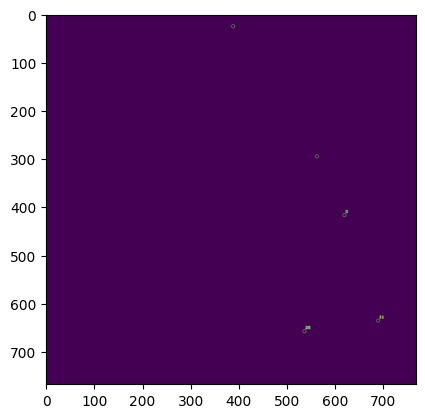

In [ ]:
plt.imshow(res_vol[6,20,2])

In [ ]:
output = r"K:\users\voland\images\cova_data\ZF_colocalisation\4-6hpf_CetnGFP_CS\results\center_pairing\pairing_mask.tif"

In [ ]:
tifffile.imwrite(output, 
                res_vol,
                imagej=True,
                compression='zlib'
                )

### Results

We can now processed to the analysis of the paired labels.
We start by extracting the spots that have been paired and isolate the alone labels.

In [ ]:
CT_paired_df = CT_center_df[CT_center_df["index"].isin(label_pair_df["CT_idx"])]
CS_paired_df = CS_center_df[CS_center_df["index"].isin(label_pair_df["CS_idx"])]

CT_unpaired_df = CT_center_df[~CT_center_df["index"].isin(label_pair_df["CT_idx"])]
CS_unpaired_df = CS_center_df[~CS_center_df["index"].isin(label_pair_df["CS_idx"])]

In [ ]:
nb_tot_CT = len(CT_center_df.index)
nb_tot_CS = len(CS_center_df.index)

nb_paired_CT = len(CT_paired_df.index)
nb_paired_CS = len(CS_paired_df.index)
assert(nb_paired_CS == nb_paired_CT)

nb_unpaired_CT = len(CT_unpaired_df.index)
nb_unpaired_CS = len(CS_unpaired_df.index)

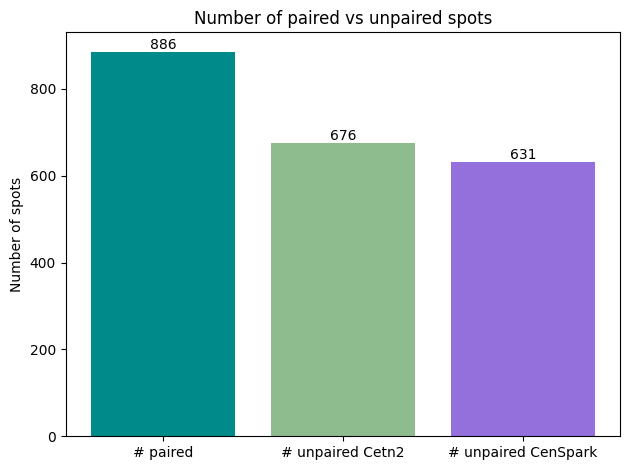

In [ ]:
pairing_nb_labels = ["# paired", "# unpaired Cetn2", "# unpaired CenSpark"]
pairing_nb = [nb_paired_CS, nb_unpaired_CT, nb_unpaired_CS]
nb_colors = ['darkcyan', 'darkseagreen', 'mediumpurple']

fig, ax = plt.subplots()
bars = ax.bar(pairing_nb_labels, pairing_nb, color=nb_colors)

ax.set_ylabel("Number of spots")
ax.set_title("Number of paired vs unpaired spots")
ax.bar_label(bars, fontsize=10)

plt.tight_layout()
plt.show()

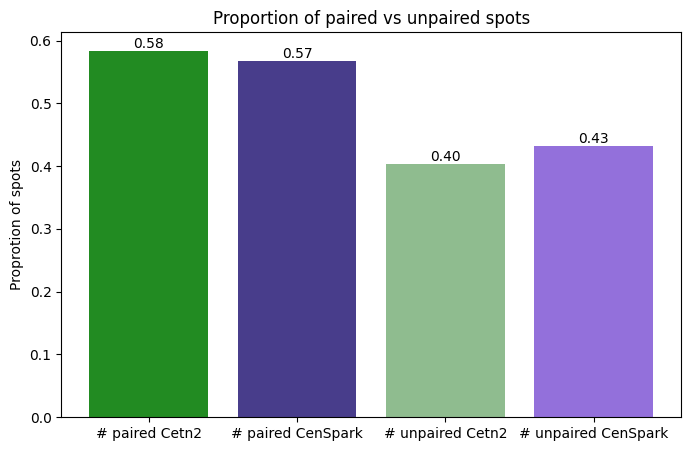

In [ ]:
pairing_proportion_labels = ["# paired Cetn2", "# paired CenSpark", "# unpaired Cetn2", "# unpaired CenSpark"]
pairing_proportions = [nb_paired_CS/nb_tot_CS, nb_paired_CT/nb_tot_CT, nb_unpaired_CS/nb_tot_CT, nb_unpaired_CT/nb_tot_CT]
proportion_colors = ['forestgreen','darkslateblue', 'darkseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(pairing_proportion_labels, pairing_proportions, color=proportion_colors)

ax.set_ylabel("Proprotion of spots")
ax.set_title("Proportion of paired vs unpaired spots")
ax.bar_label(bars, fontsize=10,fmt='%.2f')
plt.show()

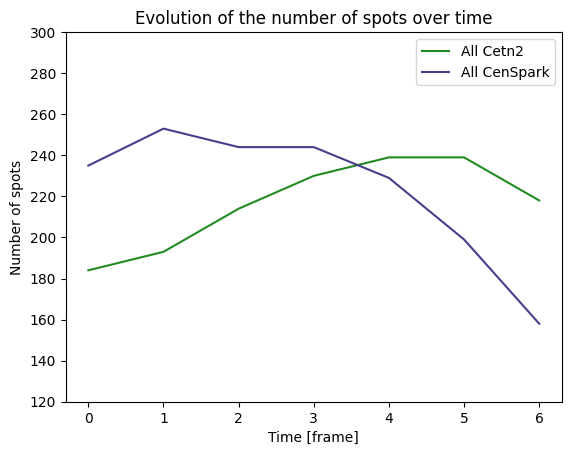

In [ ]:
pairing_data = [CS_center_df, CT_center_df]
evolution_labels = ["All Cetn2", "All CenSpark"]
evolution_colors = ['forestgreen','darkslateblue']

for i in range(len(pairing_data)):
    count_over_time = pairing_data[i].groupby(["T"]).count()["index"].values
    plt.plot(count_over_time, label = evolution_labels[i], color = evolution_colors[i])

plt.title("Evolution of the number of spots over time")
plt.xlabel("Time [frame]")
plt.ylabel("Number of spots")
plt.ylim((120,300))
plt.legend()

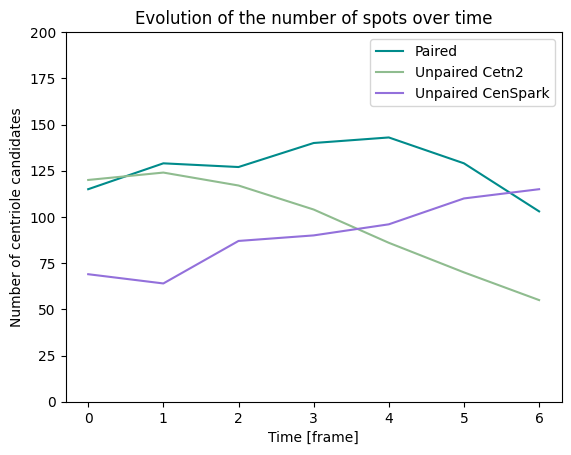

In [ ]:
pairing_data = [CS_paired_df, CT_unpaired_df, CS_unpaired_df]
evolution_labels = ["Paired", "Unpaired Cetn2", "Unpaired CenSpark"]
evolution_colors = ['darkcyan', 'darkseagreen', 'mediumpurple']

for i in range(len(pairing_data)):
    count_over_time = pairing_data[i].groupby(["T"]).count()["index"].values
    plt.plot(count_over_time, label = evolution_labels[i], color = evolution_colors[i])

plt.title("Evolution of the number of spots over time")
plt.xlabel("Time [frame]")
plt.ylabel("Number of centriole candidates")
plt.ylim((0,200))
plt.legend()